In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import json
import pandas as pd

In [ ]:
with open("new/ladder_results.json", 'r') as f:
    jsdata = json.load(f)
meta = jsdata['meta']
data = jsdata['results']
df = pd.DataFrame(data)
df

,dataset,alg,shuffle_frac,alpha,NS,SNS,FSNS
0,auto-mpg,MDS,0.00,5.704319,0.996407,0.287544,0.367974
1,auto-mpg,TSNE,0.00,5.704319,0.859366,0.410559,0.798288
2,auto-mpg,RANDOM,0.00,5.704319,0.998055,0.691967,0.863816
3,auto-mpg,MDS,0.02,0.234994,0.999853,0.299400,0.379538
4,auto-mpg,TSNE,0.02,0.234994,0.994147,0.422934,0.809555
...,...,...,...,...,...,...,...
3307,wine,TSNE,0.88,4.685020,0.905283,0.740255,1.006706
3308,wine,RANDOM,0.88,4.685020,0.995707,0.694920,0.942021
3309,wine,MDS,0.90,0.535685,0.999138,0.706429,0.982410
3310,wine,TSNE,0.90,0.535685,0.988528,0.743862,1.012064


In [ ]:
def plot_stress_ladder(dataset):
    df_sub = df[df["dataset"] == dataset]

    styles = {
        'TSNE': ('d', '-', 8),
        'RANDOM': ('o', '--', 7),
        'MDS': ('^', ':', 4),
    }

    fig, axes = plt.subplots(3, 1, figsize=(12,6), sharex=True)


    # Plot NS on ax1
    # for alg in df_sub["alg"].unique():
    for alg in styles.keys():
        marker, linestyle, markersize = styles[alg]
        sub_alg = df_sub[df_sub["alg"] == alg]
        for ax, metric in zip(axes, ['NS', 'SNS', 'FSNS']):
            ax.plot(sub_alg["shuffle_frac"], sub_alg[metric], marker=marker, linestyle=linestyle, markersize=markersize, alpha=1, label=f"{alg} - {metric}")
            ax.set_title(metric)
    

    fig.suptitle(dataset, fontsize=25)
    plt.legend()
    plt.tight_layout()

    return fig


/tmp/ipykernel_115754/90808316.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(3, 1, figsize=(12,6), sharex=True)


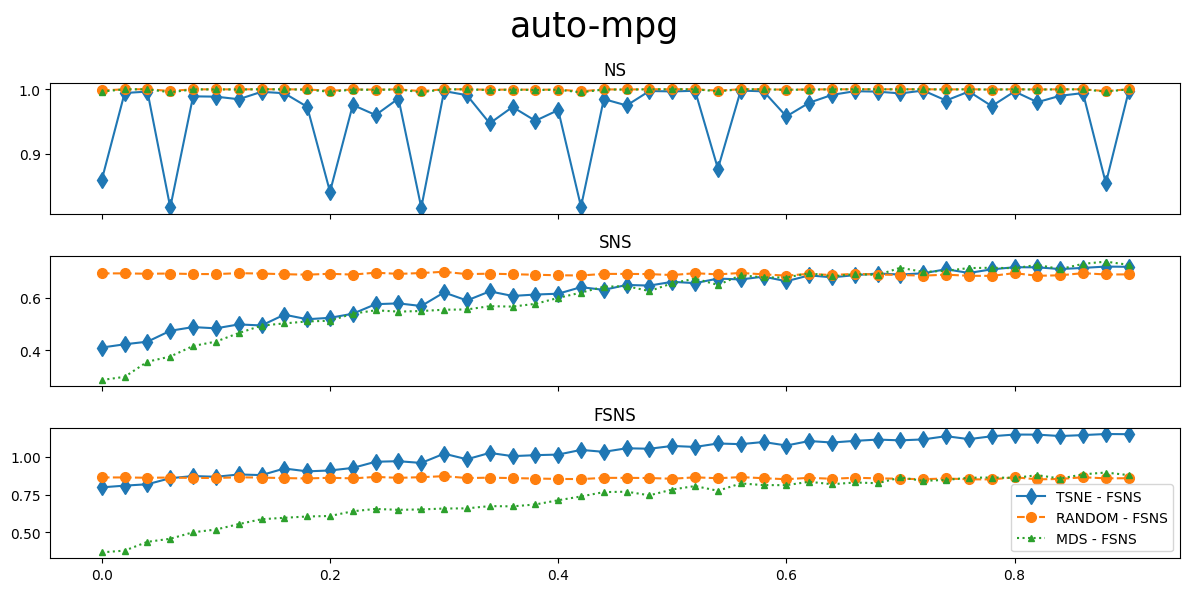

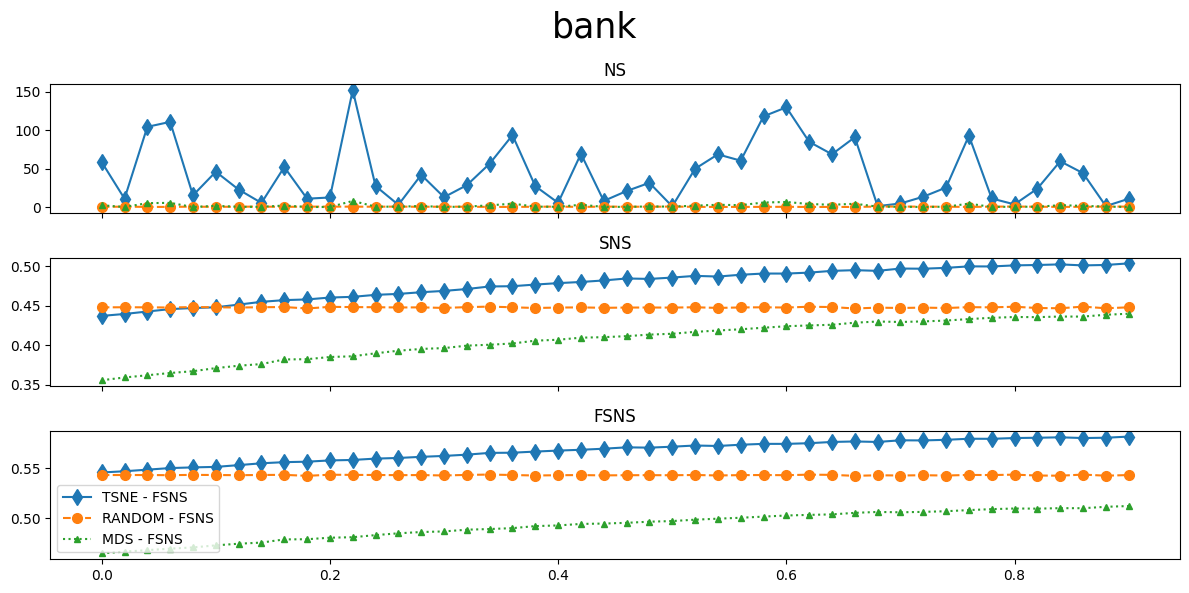

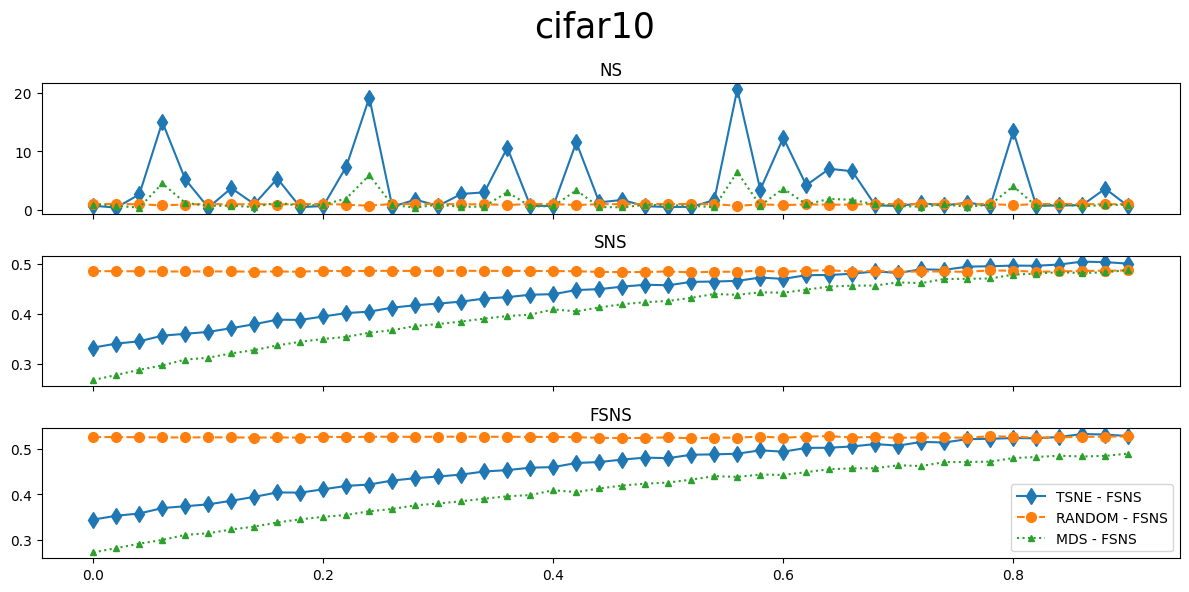

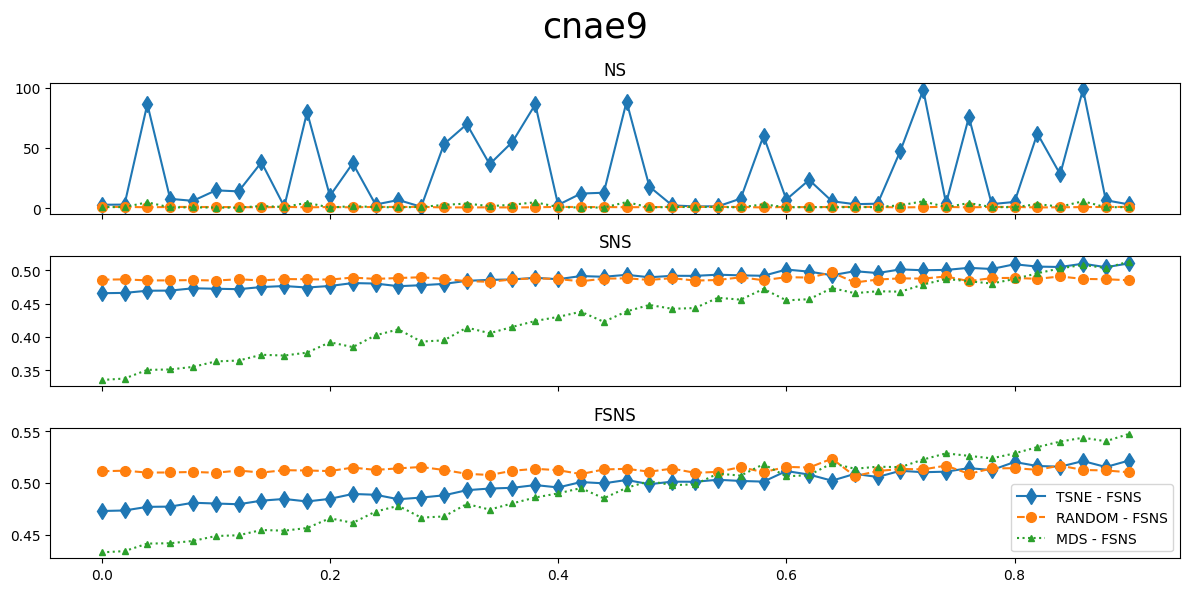

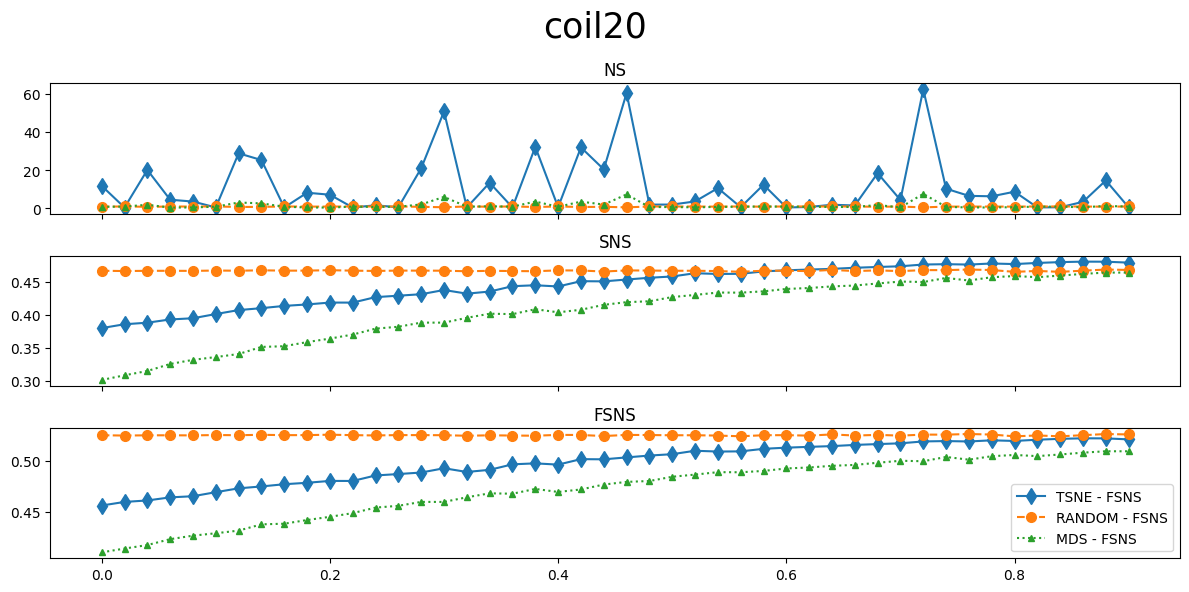

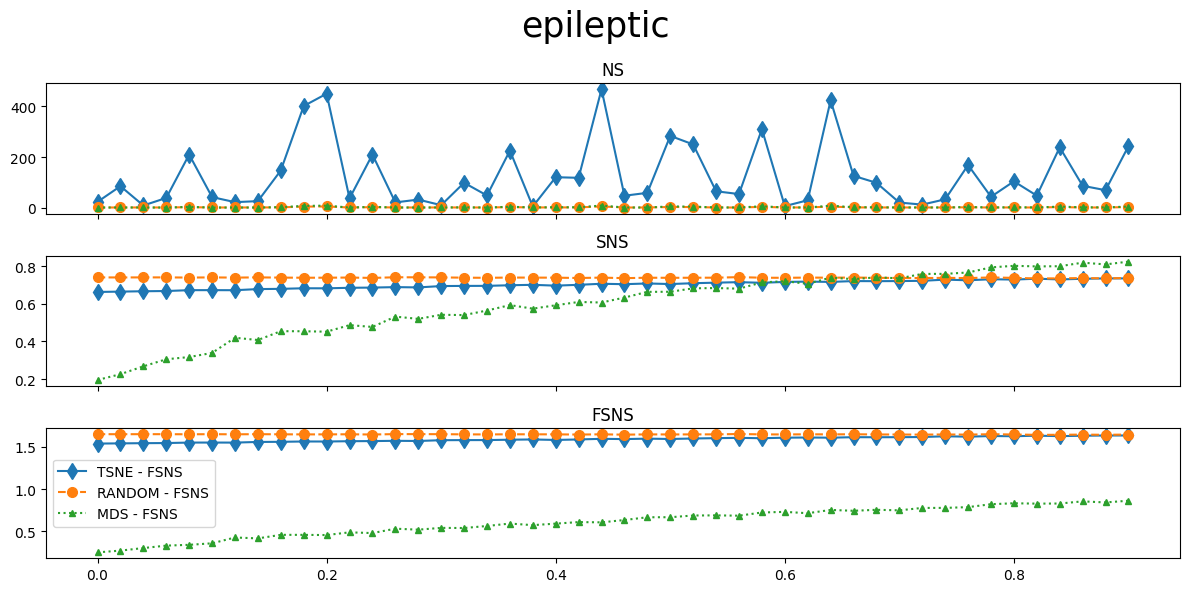

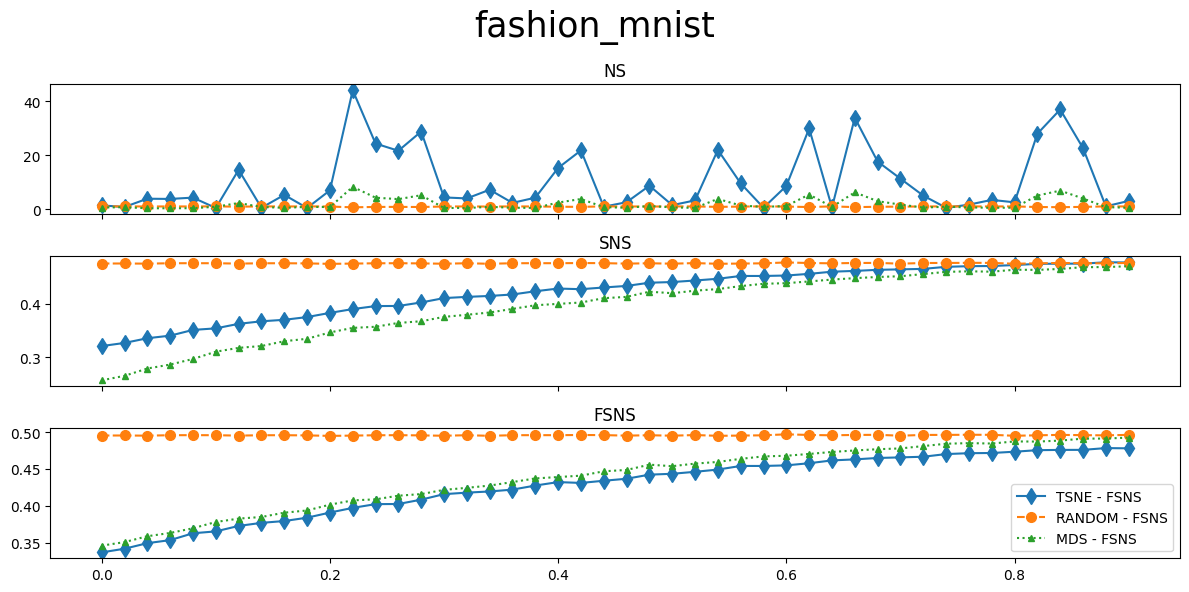

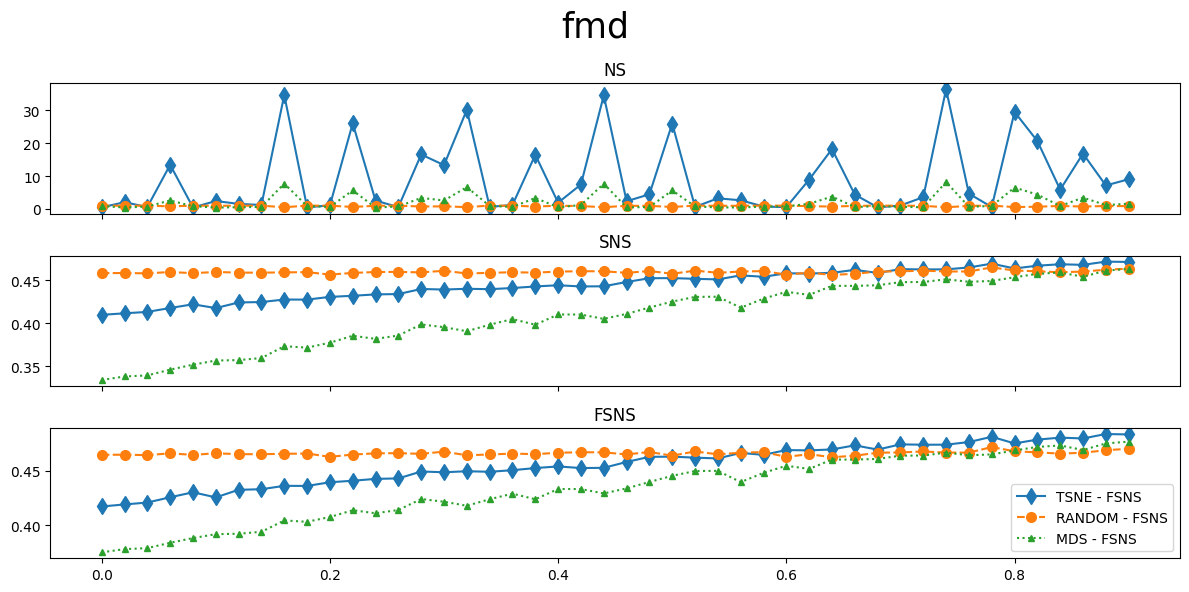

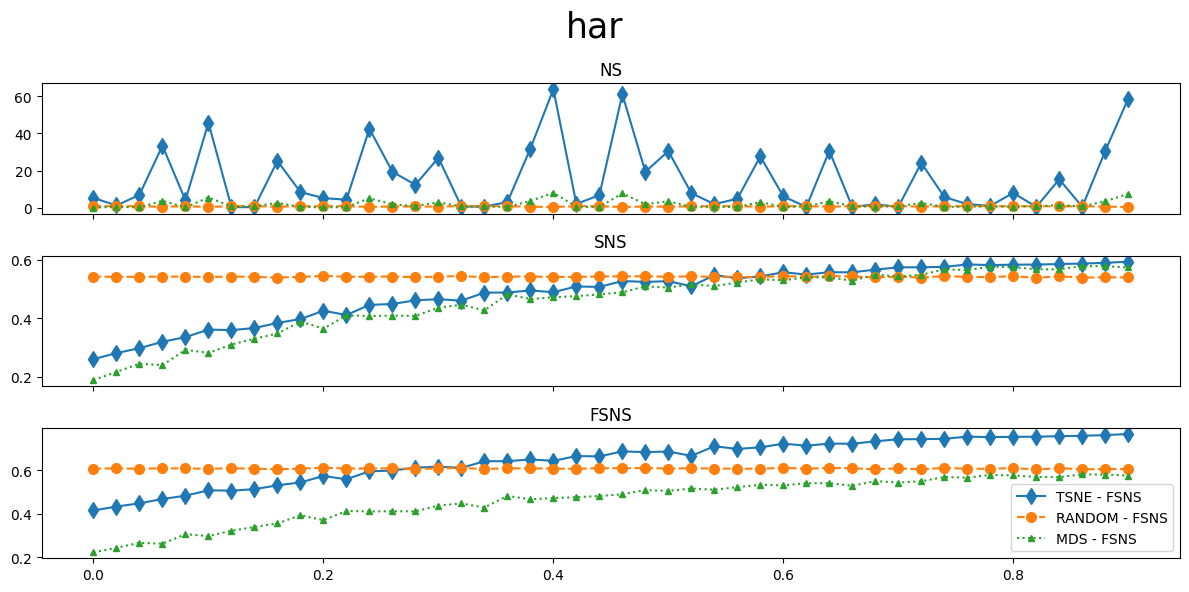

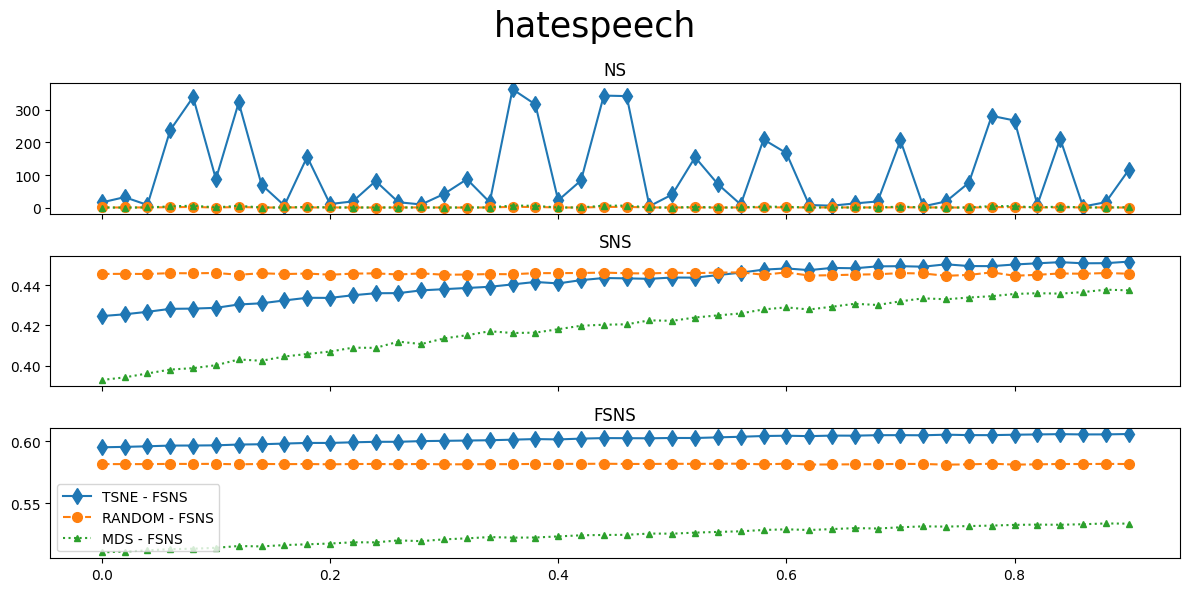

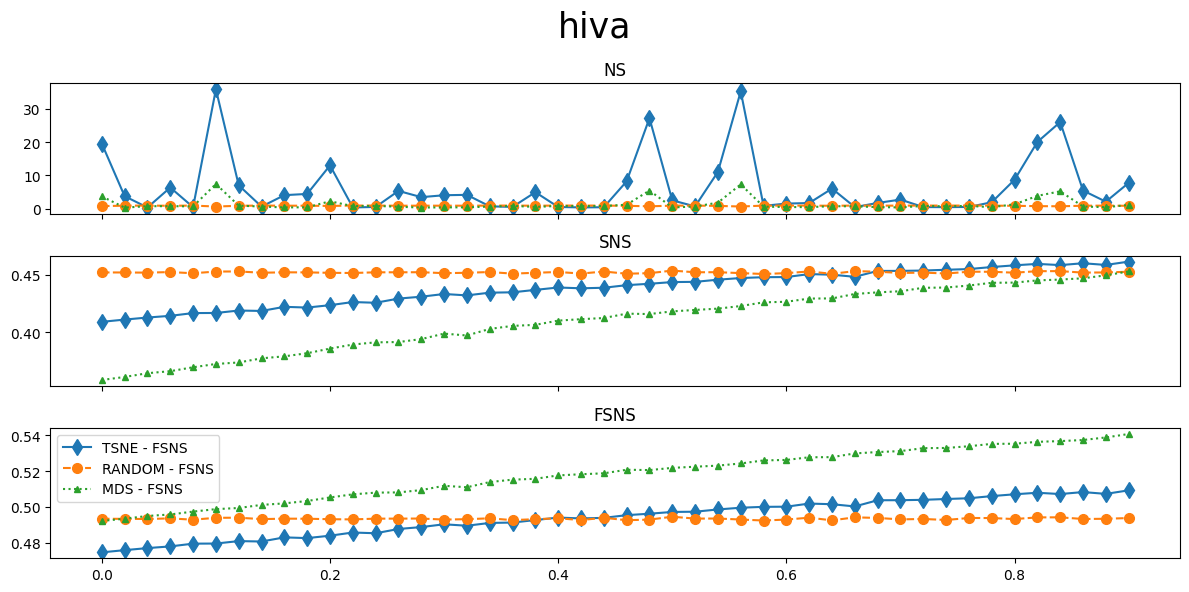

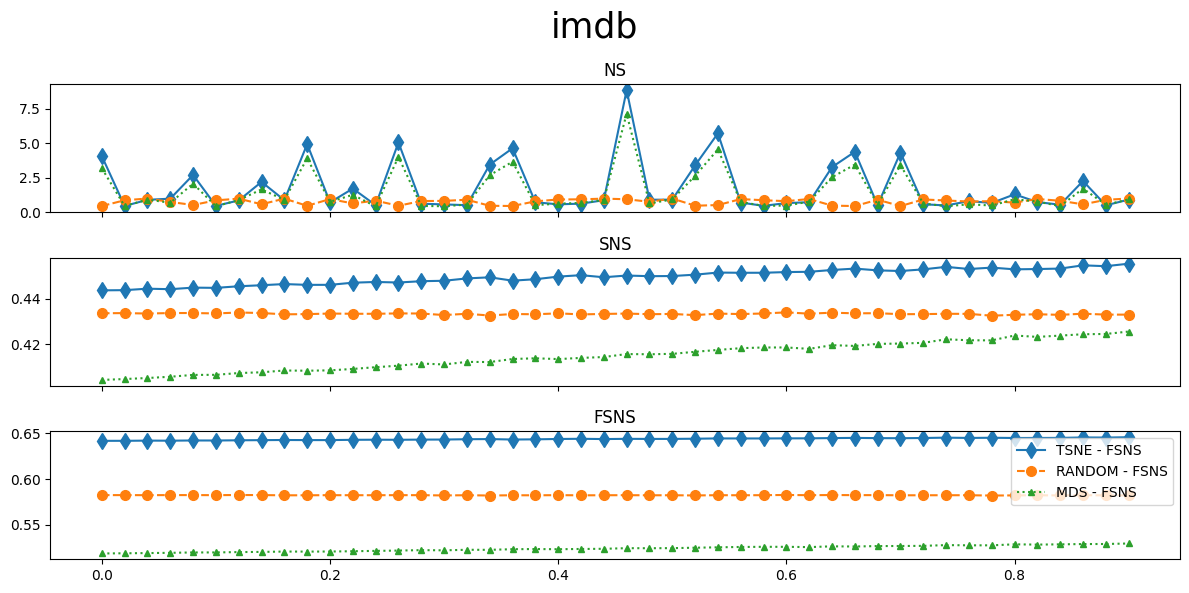

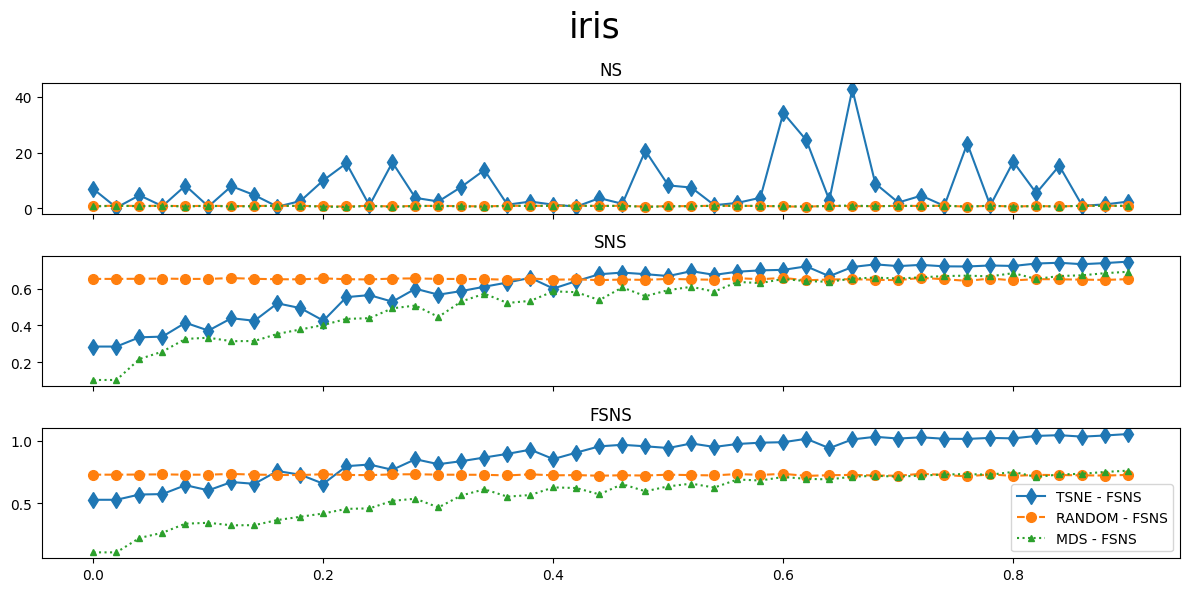

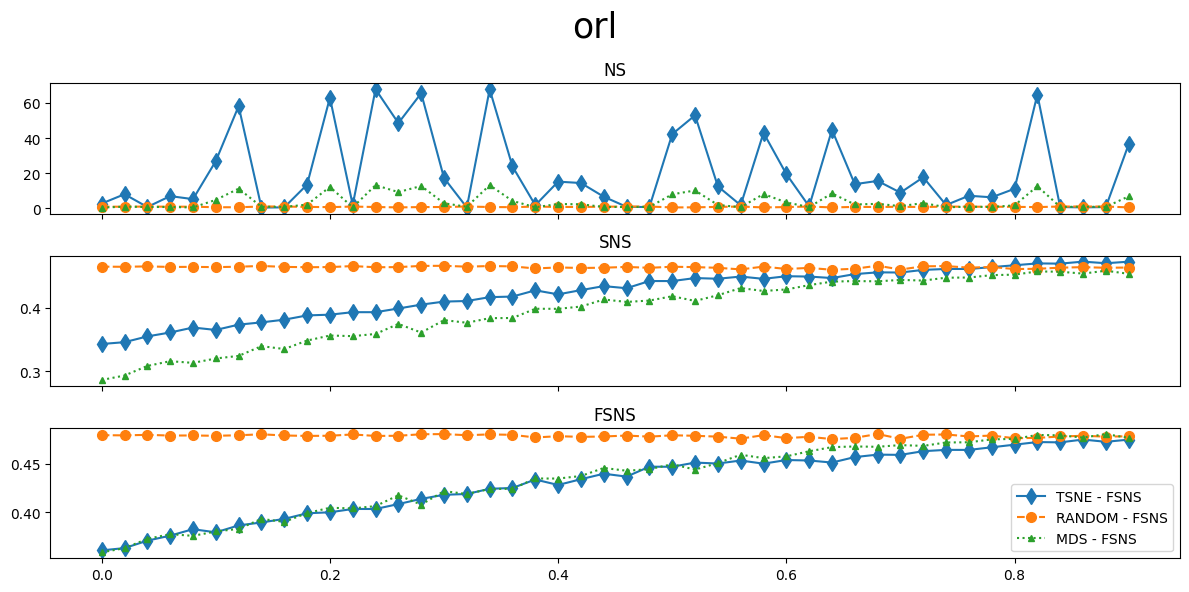

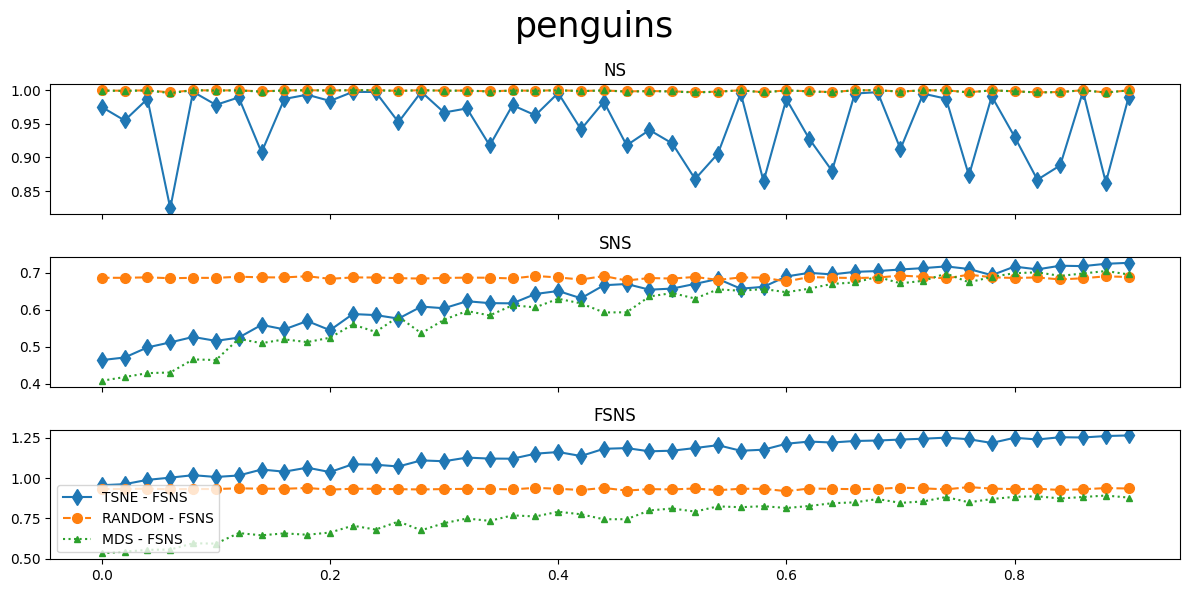

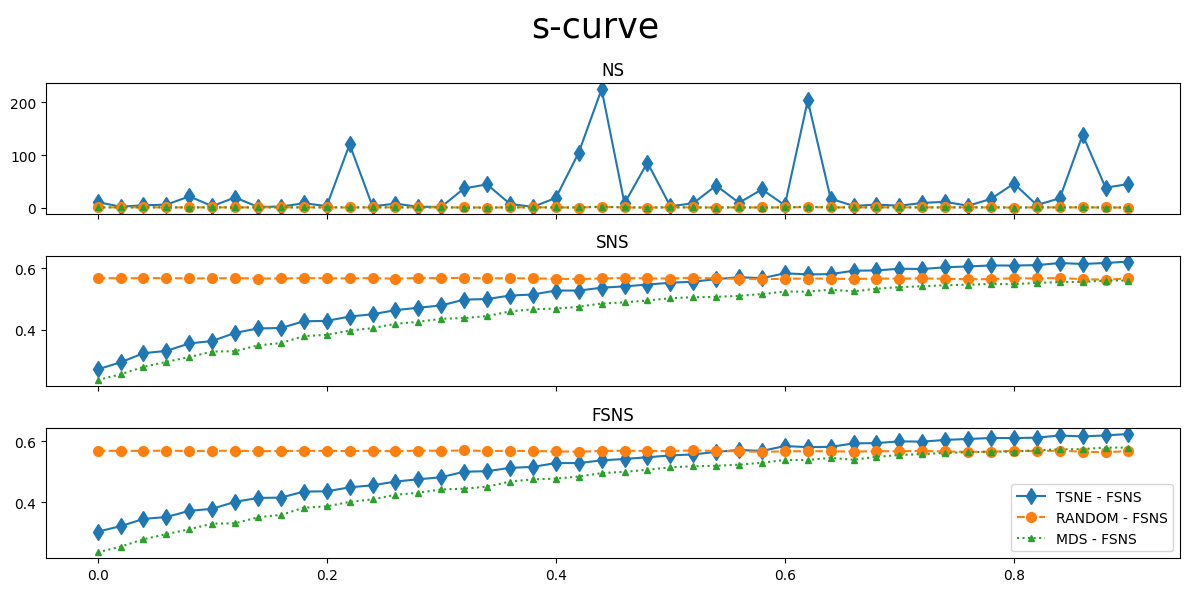

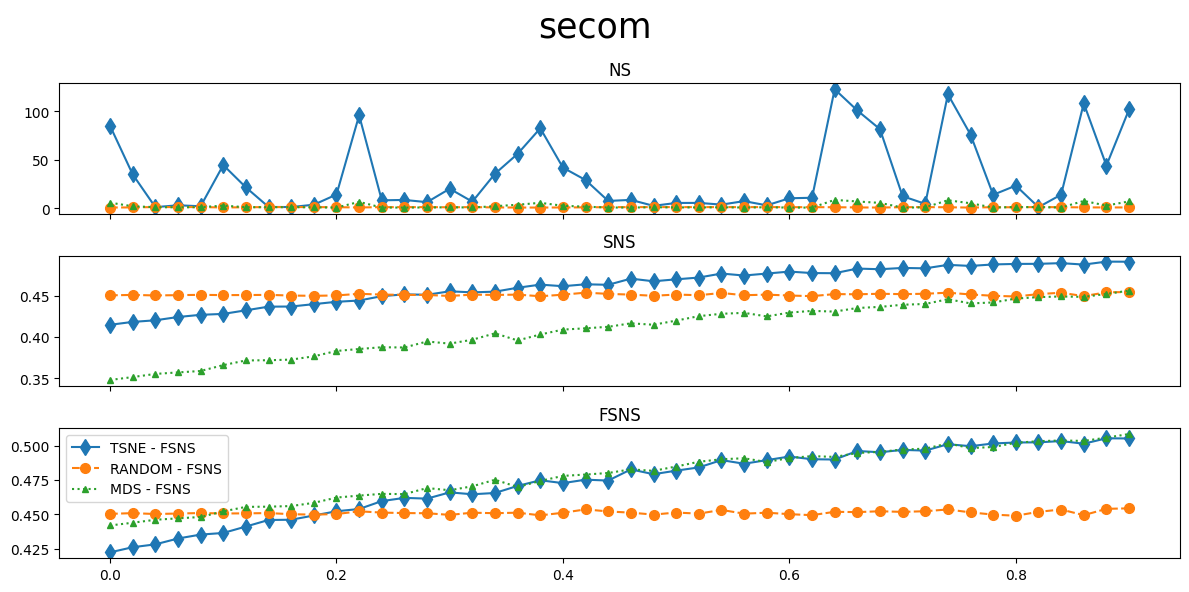

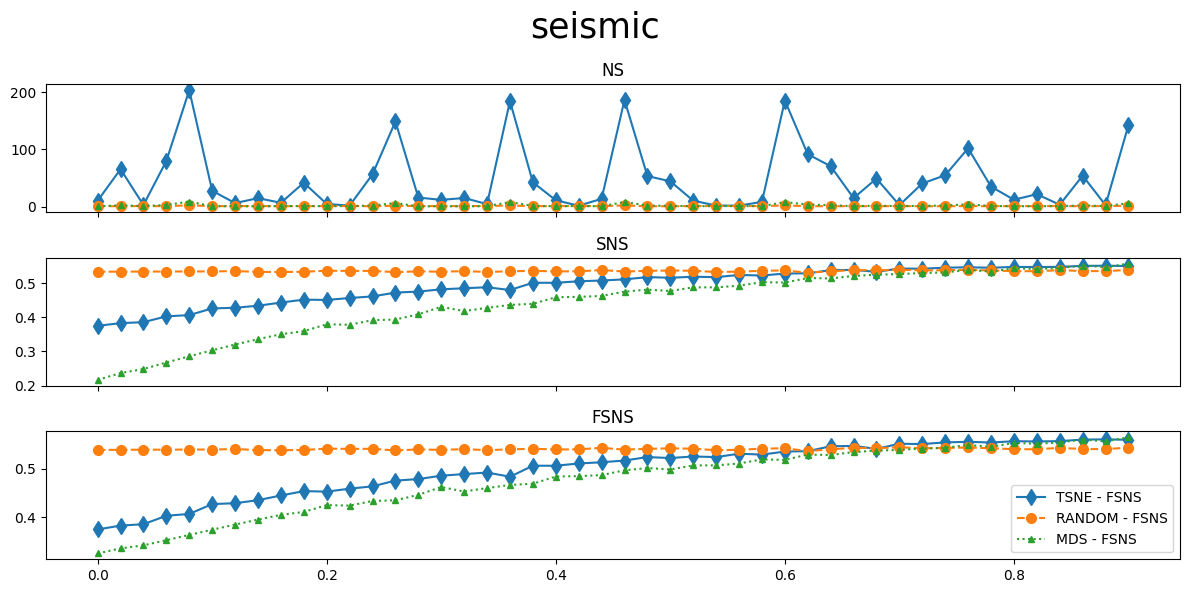

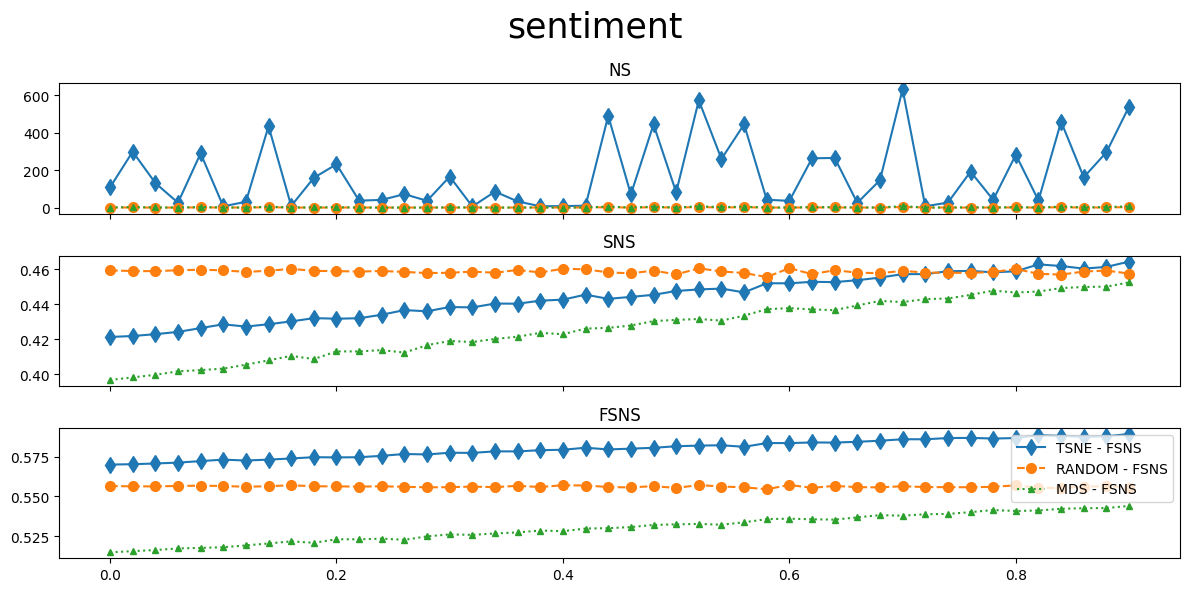

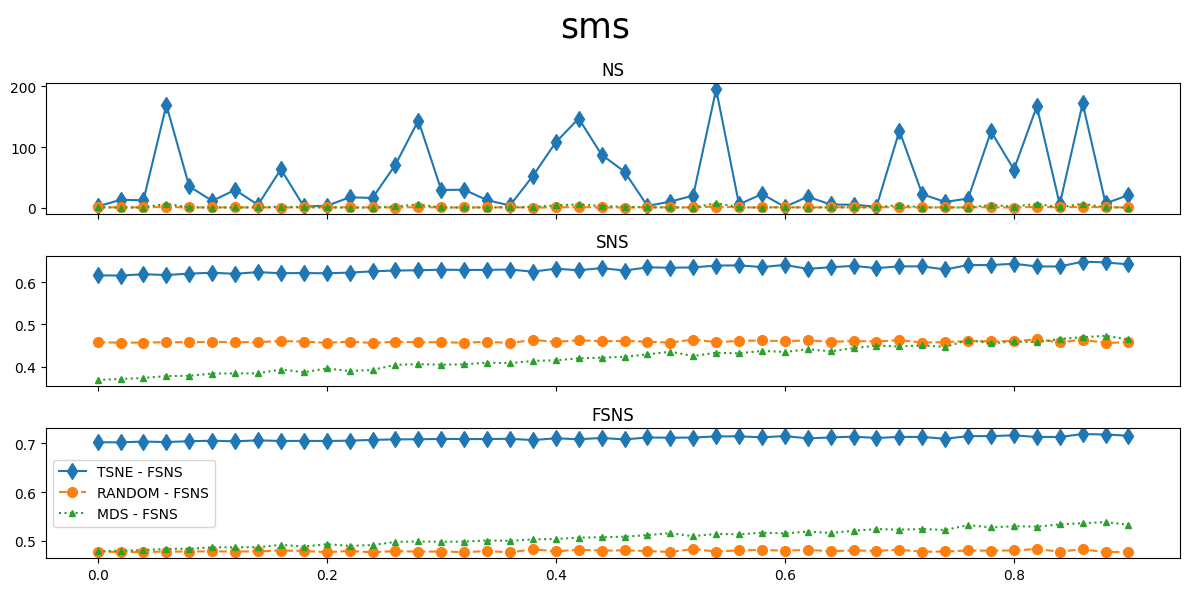

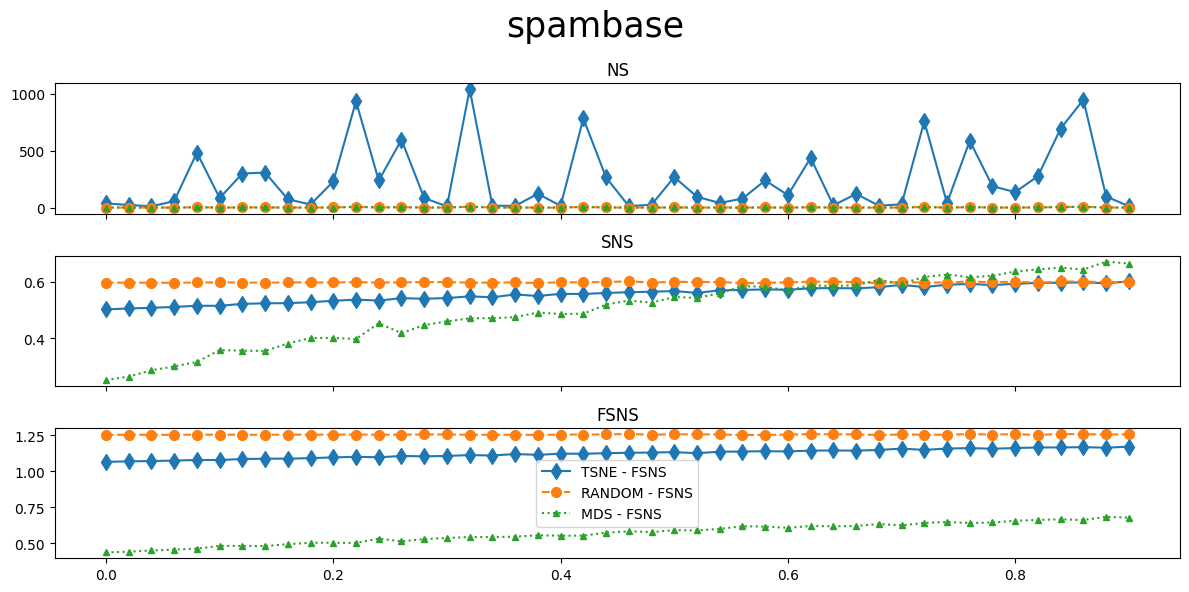

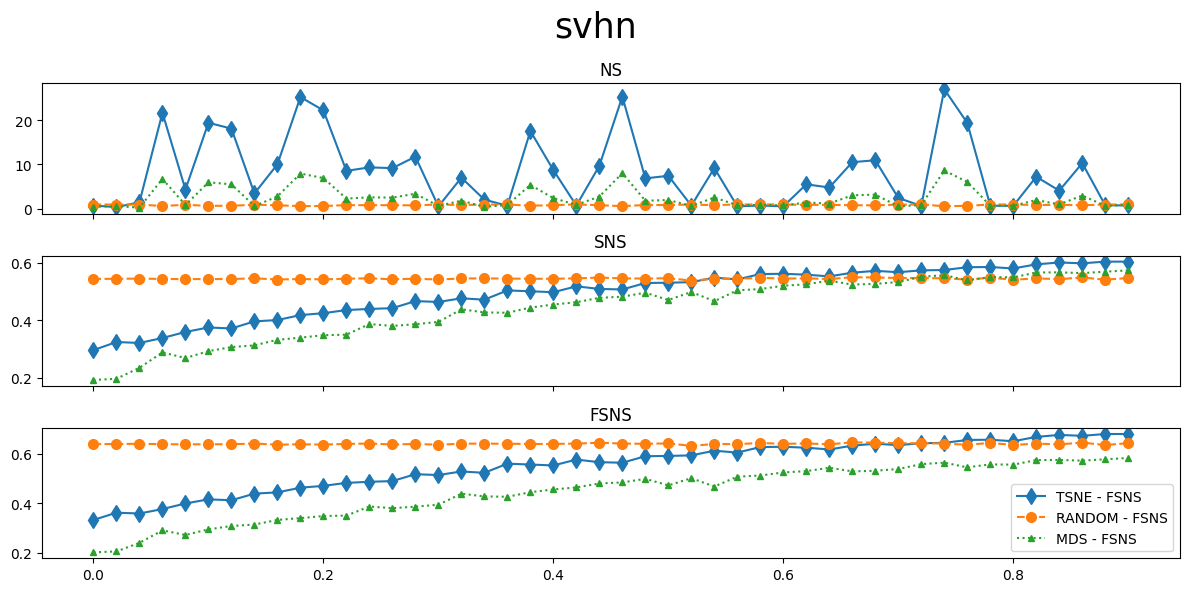

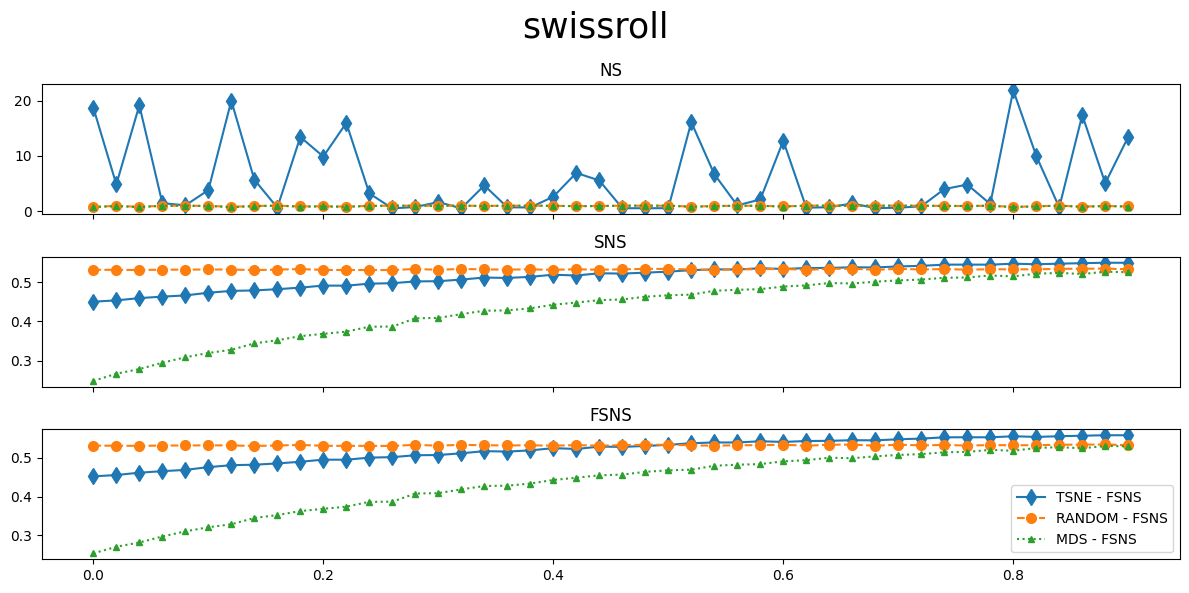

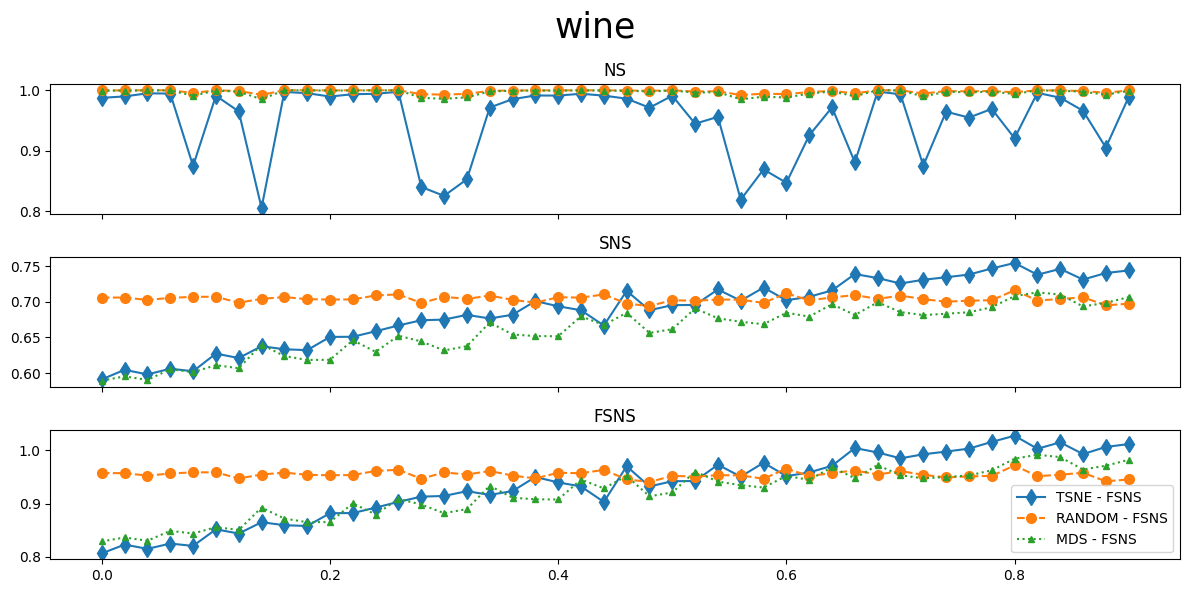

In [ ]:
from pathlib import Path
figs_dir = Path("perturb_figs")
figs_dir.mkdir(parents=True, exist_ok=True)


for dataset in df['dataset'].unique():
    fig = plot_stress_ladder(dataset)
    fig.savefig(figs_dir / f"{dataset}.png", format='png')
    # plt.close()
    